# Anomaly Detection for Regression Unlabled Data

This notebook demonstrates how to perform anomaly detection for a continuous unlabeled target variable using time series regression.
For this demonstration, we use the cleaned Walmart dataset. We will analyze the time series sales data and use it for detecting anomalies in overall sales.

The algorithm developed and deployed in this notebook will later be used in another project (under the same parent folder) for daily monitoring and anomaly detection in production.

The notebook covers the following topics:
1. Dataset overview and exploratory data analysis
2. Time series modeling, validation, and its application to anomaly detection
3. Custom model registration and deployment
4. Model invocation



Data resource: https://www.kaggle.com/datasets/ujjwalchowdhury/walmartcleaned \
Conda environment: generalml_p311_cpu_x86_64_v1

Author: Assaf Rabinowicz, Data Science Team, EMEA

# Importing Packages and Data

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

import oci
from oci.auth.signers import get_resource_principals_signer
import ads
from ads.model.generic_model import GenericModel

#Importing three helpers modules 
import utils
import graphs
import models

ads.set_auth(auth='resource_principal')

In [69]:
path='/home/datascience/anomaly_detection_project/regression/data/walmart_train.csv' # the data was copied and paste to the Notebook Block volume
df = pd.read_csv(path)
df.shape

(383040, 18)

In [70]:
display(df.head())
display(df.dtypes.to_frame('dtype'))

,Unnamed: 0.1,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,0,0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
1,330761,332087,35,2010-02-05,0,83.0,5015.30,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681
2,330762,332088,35,2010-02-05,0,95.0,62831.98,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681
3,330763,332089,35,2010-02-05,0,26.0,10870.40,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681
4,330764,332090,35,2010-02-05,0,56.0,345.00,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681


,dtype
Unnamed: 0.1,int64
Unnamed: 0,int64
Store,int64
Date,str
IsHoliday,int64
Dept,float64
Weekly_Sales,float64
Temperature,float64
Fuel_Price,float64
MarkDown1,float64


* The data includes the following hierarchy: Walmart consists of multiple stores, and each store contains multiple departments (Dept).
* In addition, the dataset is time-series based, meaning that each store-department combination appears on a weekly basis.
* Besides the structural columns, the dataset also contains several additional features that can be used as input variables for the model.

# Data Processing and Exploration

In [71]:
# The data is relatively clean; only a few minor adjustments are required:
# dropping the index column and converting the Date column to datetime format.

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Shape: 383,040 rows x 17 columns


In [73]:
# Checking missing values by column.

missing = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isna().sum().values,
})
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(3)
missing = missing.sort_values(['missing_count', 'column'], ascending=[False, True]).reset_index(drop=True)
missing_nonzero = missing[missing['missing_count'] > 0].reset_index(drop=True)

if missing_nonzero.empty:
    print('There are no missing values.')
else:
    display(missing_nonzero)
    print('Columns with missing values:', len(missing_nonzero))

There are no missing values.


In [72]:
# Let's separate the variables into numerical and categorical groups
# in order to inspect the basic statistics for each group.

num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns (16): ['Unnamed: 0.1', 'Store', 'IsHoliday', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']
Categorical columns (0): []


In [74]:
if num_cols:
    num_desc = df[num_cols].describe()
    num_desc = num_desc.drop(index=['25%', '75%'], errors='ignore')
    display(num_desc)
else:
    print('No numerical columns found.')

,Unnamed: 0.1,Store,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
count,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000,383040.00000,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000,383040.000000
mean,210287.787153,22.193797,0.069692,44.243599,16017.546461,59.029180,3.317363,2096.169787,964.15273,511.620121,898.072541,1416.678974,170.748664,8.042668,2.410516,136768.145870
std,121687.023644,12.782512,0.254628,30.473053,22786.408121,18.653297,0.453193,5568.159572,5326.78905,5798.466066,3805.301164,4228.839267,38.965892,1.863513,0.665964,60962.131332
min,0.000000,1.000000,0.000000,1.000000,-4988.940000,-2.060000,2.472000,0.000000,-265.76000,-29.100000,0.000000,0.000000,126.064000,4.077000,1.000000,34875.000000
50%,210402.500000,22.000000,0.000000,37.000000,7630.350000,60.420000,3.353000,0.000000,0.00000,0.000000,0.000000,0.000000,182.260441,7.907000,3.000000,140167.000000
max,420693.000000,45.000000,1.000000,99.000000,693099.360000,100.140000,4.308000,88646.760000,104519.54000,141630.610000,67474.850000,108519.280000,225.697078,14.313000,3.000000,219622.000000


In [75]:
# The data can be analyzed in different ways. In this demonstration, we focus on overall sales rather than on a specific store.
# Still, as shown in the graph below, the weekly sales of individual stores are highly correlated with the overall weekly sales across all stores.
agg_df = utils.create_aggregated_df(df)
print(f'Shape: {agg_df.shape[0]:,} rows x {agg_df.shape[1]} columns')
agg_df.head()

Shape: 130 rows x 16 columns


,Date,Store,Dept,IsHoliday,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,2010-02-05,45,2955,0,49750740.50,33.277942,2.717869,0.0,0.0,0.0,0.0,0.0,167.398405,8.576731,2.412183,137430.535364
1,2010-02-12,45,2956,2956,48336677.63,33.361810,2.696102,0.0,0.0,0.0,0.0,0.0,167.384138,8.567309,2.414073,137622.780785
2,2010-02-19,45,2977,0,48276993.78,37.038310,2.673666,0.0,0.0,0.0,0.0,0.0,167.338966,8.576351,2.412160,137278.637219
3,2010-02-26,45,2951,0,43968571.13,38.629563,2.685642,0.0,0.0,0.0,0.0,0.0,167.691019,8.561375,2.412064,137346.344629
4,2010-03-05,45,2944,0,46871470.30,42.373998,2.731816,0.0,0.0,0.0,0.0,0.0,167.727351,8.572689,2.414062,137576.841033


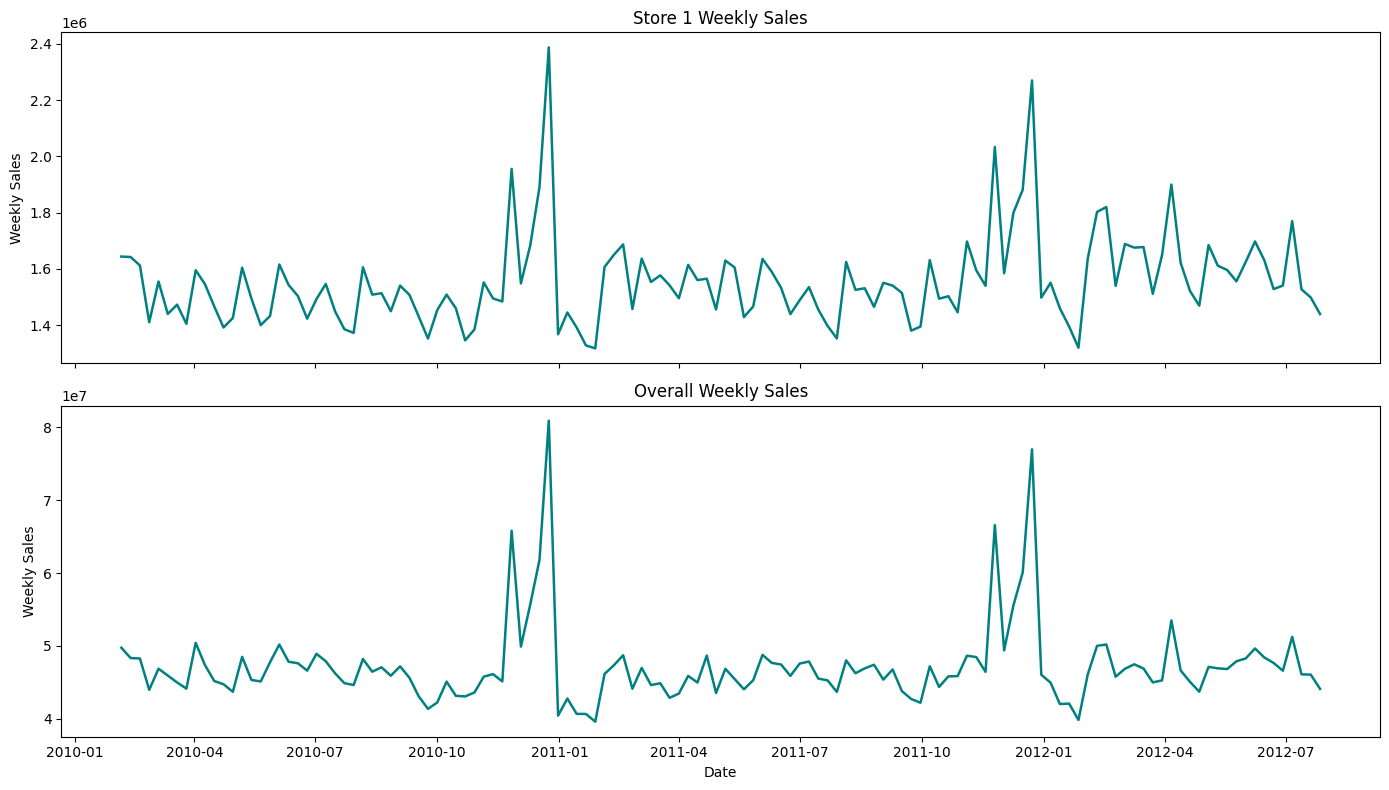

In [76]:
graphs.plot_store_vs_overall_sales(df, agg_df, store_id=1, sales_col='Weekly_Sales', date_col='Date')

In [77]:
train_df = agg_df.iloc[:120]
test_df = agg_df.iloc[120:130]

# Modeling and Validation

* Time series data can be analyzed using a wide range of models. In this demonstration, we focus on a model that satisfies the following requirements:
    a. Supports forecasting, rather than only retrospective analysis
    b. Allows enriching the time series model with additional features, rather than relying solely on the raw time series
    c. Provides flexibility in modeling different correlation structures within the data
* The SARIMAX model was selected. Although it is limited to capturing primarily linear relationships, it is a powerful and flexible model that allows customization of several important components:
    - Autoregressive effect (AR) - previous observations are used to predict future values
    - Moving Average effect (MA) - previous prediction errors are used to improve short-term forecasting accuracy
    - Differencing effect - the original series is transformed using differencing to improve stationarity and stabilize parameter estimation. Predictions are later transformed back into the original time-series scale
    - Seasonality effect - seasonal patterns are modeled using the same concepts (AR, MA, and differencing), but applied to the seasonal structure embedded in the data. In our case, we assume yearly seasonality (52 weeks), meaning that the seasonal component is modeled using a lag of 52 observations
    - Exogenous features - additional variables are incorporated into the model as exogenous predictors to improve forecasting performance
The order of the AR, MA, and differencing components can be adjusted in the model.
* Different parameter combinations may be explored, and various diagnostic plots and statistical methods can assist in selecting appropriate orders.
    - In this demonstration, we simplify the process by using: AR order = 1, MA order = 1 for regular components, and seasonal AR and MA orders are set to 0
    - Differencing order = 1 for both, for both the regular and seasonal components.
    - One of the reason for setting seasonal AR and MA orders are set to 0 is the relatively small time-series data (only 120 samples for train)
* In addition to forecasting, the model also provides upper and lower prediction intervals for each predicted point. These intervals can be used for anomaly detection by defining observations whose actual weekly sales fall outside the interval as anomalies.
* Note that the prediction interval represents the estimated range within which future observations are expected to fall with high probability (95% confidence in this example). This confidence level, and consequently the width of the interval, can be adjusted based on the use case.

In [78]:
sales_col = 'Weekly_Sales'
date_col = 'Date'

order_value = (1,1,1) #(AR order, Difference order, MA order)
seasonal_order_value = (0,1,0,52) #(AR seasonality order, Difference seasonality order, MA seasonality order, Seasonal perdiod)

In [62]:
# We first start using all features for modeling
trend_cols = ['Store','Dept','IsHoliday','Temperature','Fuel_Price','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment','Type','Size']

results = models.fit_model(train_df,
    order_value,
    seasonal_order_value,
    trend_cols,
    sales_col
)

                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 52)   Log Likelihood               -1033.368
Date:                             Wed, 13 May 2026   AIC                           2098.737
Time:                                     07:20:05   BIC                           2133.527
Sample:                                          0   HQIC                          2112.464
                                             - 120                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Store        -2.243e-07   6.59e+04   -3.4e-12      1.000   -1.29e+05    1.29e+05
Dept          2.651e+

* The P>|z| column in the report indicates that several features are not statistically significant.
* These features could potentially be removed in order to simplify the model and improve its interpretability.

In [79]:
trend_cols = ['Dept','Temperature','Fuel_Price','CPI','Unemployment','Type','Size'] # simplified model

results = models.fit_model(train_df,
    order_value,
    seasonal_order_value,
    trend_cols,
    sales_col
)

                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 52)   Log Likelihood               -1040.944
Date:                             Wed, 13 May 2026   AIC                           2101.888
Time:                                     08:01:05   BIC                           2123.632
Sample:                                          0   HQIC                          2110.468
                                             - 120                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Dept          2.161e+04   1.64e+04      1.315      0.189   -1.06e+04    5.38e+04
Temperature   1.403e+

* Once the model is fitted, we can evaluate its performance on the test dataset.
* There are two common ways for forecasting the test set, which in this case contains 10 samples:

  1. Multi-step forecasting - forecast all test samples at once using the model fitted up to sample 120.
  2. Walk-forward forecasting - iteratively forecast the next sample and then update the model using the newly observed value, and therefore it is more accurate.

* Each approach is suitable for different use cases:
  * If the production model is expected to remain static, the first approach is more appropriate.
  * If the model can be continuously updated with new observations, the walk-forward approach is preferred.

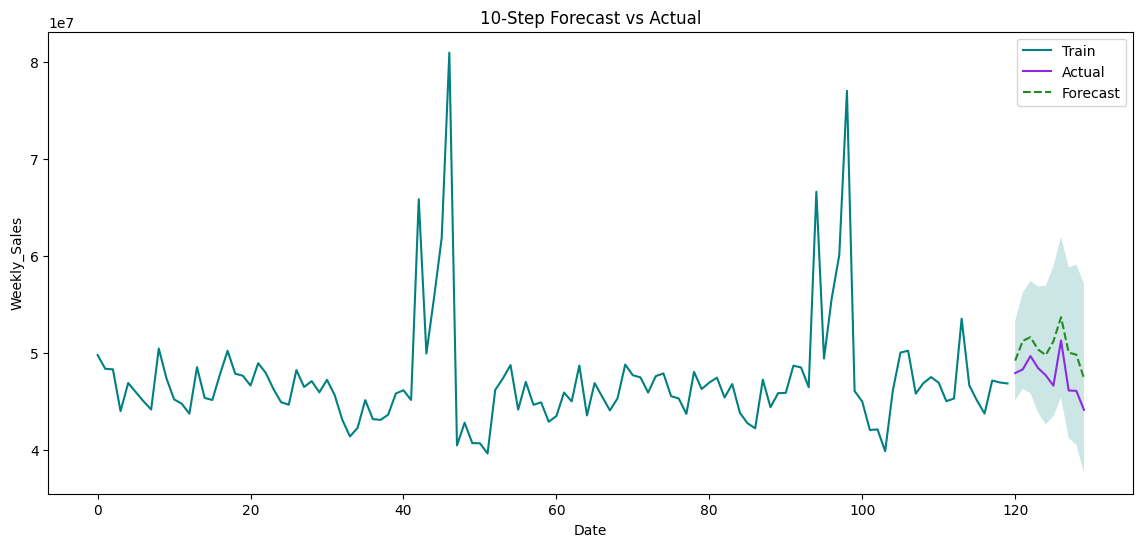

In [80]:
X_test = test_df[trend_cols]

forecast_obj = results.get_forecast(
    steps=len(test_df),
    exog=X_test
)

forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

graphs.plot_forecast(
    train_df=train_df,
    test_df=test_df,
    sales_col=sales_col,
    forecast=forecast,
    conf_int=conf_int,
    title='10-Step Forecast vs Actual'
)

In [81]:
forecast_series, conf_int_df = utils.walk_forward_forecast(
    results=results,
    test_df=test_df,
    trend_cols=trend_cols,
    sales_col=sales_col
)

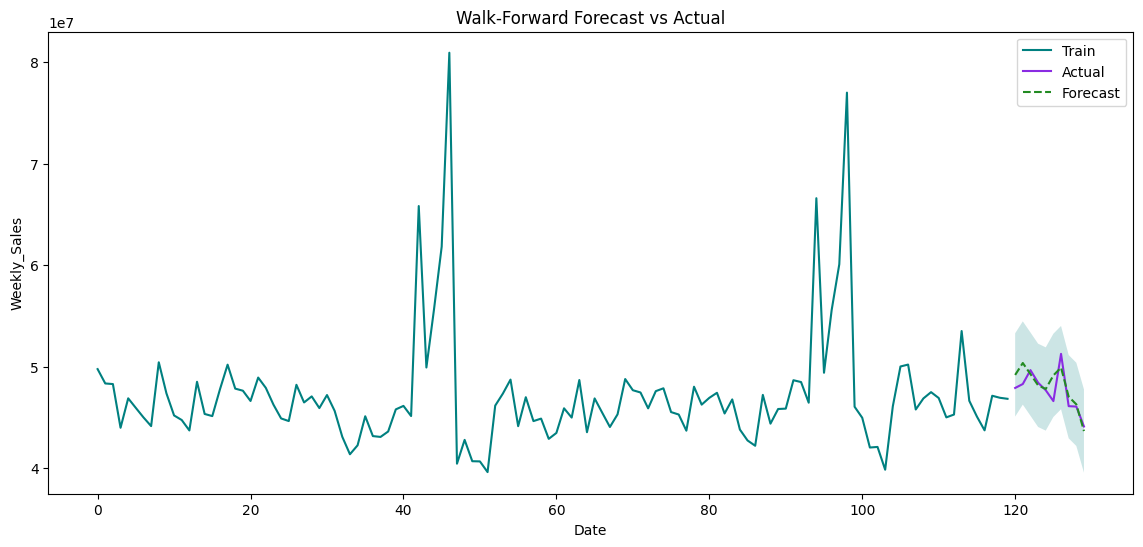

In [82]:
graphs.plot_forecast(
    train_df=train_df,
    test_df=test_df,
    sales_col=sales_col,
    forecast=forecast_series,
    conf_int=conf_int_df,
    title='Walk-Forward Forecast vs Actual'
)

# Model Registration and Deployment

* Here we use ADS to simplify model artifact preparation for model registration in the OCI Data Science Model Catalog and deployment to a dedicated model deployment server.
* ADS supports two approaches for model artifact preparation:
    - ADS Models: ADS provides direct support for frameworks such as Scikit-learn, PyTorch, XGBoost, and others. In these cases, the generated artifacts are framework-specific and typically do not require customization.
    - ADS Generic: ADS provides an initial artifact template, which may sometimes be sufficient as-is, but in many cases requires minor adjustments. This is the approach used here, since the statsmodels framework, from which the SARIMAX model is imported, is not currently included in the list of supported ADS Models.
* For ADS documentation: https://accelerated-data-science.readthedocs.io/en/latest/user_guide/model_registration/introduction.html
* Other resources focus on model regitration and deployment are also publicly available: https://github.com/oracle-devrel/technology-engineering/tree/main/data-platform/data-science/oracle-data-science/customizing-ads-model-deployment-artifacts

In [114]:
artifact_dir = '/home/datascience/anomaly_detection_project/regression/artifact2' # local folder for saving the prepared artifacts temporarily
X_sample = train_df[trend_cols].iloc[[0]].copy()
print(X_sample)

   Dept  Temperature  Fuel_Price         CPI  Unemployment      Type  \
0  2955    33.277942    2.717869  167.398405      8.576731  2.412183   

            Size  
0  137430.535364  


In [115]:
artifact_object = GenericModel(estimator=results,
                            artifact_dir=artifact_dir)

In [124]:
# Here we use a custom inference_conda_env, since additional packages were installed in the `generalml_p311_cpu_x86_64_v1` environment and should also be available in production
artifact_object.prepare(inference_conda_env='<path-to-published-conda>',
                        inference_python_version="3.11",
                        X_sample=X_sample,
                        force_overwrite=True)

                                                                                                                                                                                                                                                       ?, ?it/s]

algorithm: null
artifact_dir:
  /home/datascience/anomaly_detection_project/regression/artifact2:
  - - input_schema.json
    - .model-ignore
    - test_json_output.json
    - score.py
    - model.pkl
    - runtime.yaml
    - .ipynb_checkpoints
    - .ipynb_checkpoints/runtime-checkpoint.yaml
framework: null
model_deployment_id: null
model_id: null

* Some modifications are required in the prepared artifacts:
  * In `score.py`:
    * Adjust the `predict` function to extract the SARIMAX forecast, along with the lower and upper confidence bounds used for anomaly detection (see the example in the `artifact example` folder).
    * Update the dataframe deserialization logic to use `StringIO` when reading JSON input.
    * Import `StringIO` at the beginning of the file.
  * In `runtime.yaml`:
    * Replace the default `INFERENCE_ENV_PATH` value with the path specified in the `prepare()` function.
* After applying these adjustments, use the `reload()` method to reload the updated artifacts into memory.
* Then, we will verify and inspect the artifacts to ensure they are ready for registration and deployment.

In [125]:
artifact_object.reload()

Start loading model.pkl from model directory /home/datascience/anomaly_detection_project/regression/artifact2 ...
Model is successfully loaded.


algorithm: null
artifact_dir:
  /home/datascience/anomaly_detection_project/regression/artifact2:
  - - input_schema.json
    - .model-ignore
    - test_json_output.json
    - score.py
    - model.pkl
    - runtime.yaml
framework: null
model_deployment_id: null
model_id: null

In [126]:
artifact_object.verify(X_sample, auto_serialize_data=True)

Start loading model.pkl from model directory /home/datascience/anomaly_detection_project/regression/artifact2 ...
Model is successfully loaded.


{'prediction': 39198244.41113508,
 'lower_prediction_interval': 35093432.406648,
 'upper_prediction_interval': 43303056.41562215}

In [127]:
artifact_object.introspect()

['input_schema.json', '.model-ignore', 'test_json_output.json', 'score.py', 'model.pkl', 'runtime.yaml']


,Test key,Test name,Result,Message
0,runtime_env_path,Check that field MODEL_DEPLOYMENT.INFERENCE_ENV_PATH is set,Passed,
1,runtime_env_python,Check that field MODEL_DEPLOYMENT.INFERENCE_PYTHON_VERSION is set to a value of 3.6 or higher,Passed,
2,runtime_path_exist,Check that the file path in MODEL_DEPLOYMENT.INFERENCE_ENV_PATH is correct.,Passed,
3,runtime_version,Check that field MODEL_ARTIFACT_VERSION is set to 3.0,Passed,
4,runtime_yaml,"Check that the file ""runtime.yaml"" exists and is in the top level directory of the artifact directory",Passed,
5,score_load_model,Check that load_model() is defined,Passed,
6,score_predict,Check that predict() is defined,Passed,
7,score_predict_arg,Check that all other arguments in predict() are optional and have default values,Passed,
8,score_predict_data,"Check that the only required argument for predict() is named ""data""",Passed,
9,score_py,"Check that the file ""score.py"" exists and is in the top level directory of the artifact directory",Passed,


In [ ]:
# Model registration in the model catalog
model_id = artifact_object.save(
    display_name="walmart_sarimax_2",
    description="time series regression for anomaly detection.",
    ignore_pending_changes=True)

print(f"Model saved: {model_id}")

In [ ]:
# Model deployment
deployed_model = artifact_object.deploy(
    display_name="walmart_sarimax_2", 
    deployment_log_group_id="<enter-log-group-ocid>",
    deployment_predict_log_id="<enter-log-ocid>",
    deployment_instance_shape="VM.Standard.E4.Flex",
    deployment_ocpus=1,
    deployment_memory_in_gbs=16
)

# Scoring

In [136]:
endpoint = "<your_endpoint>"

In [141]:
payload = X_sample.to_dict(orient="list")

response = requests.post(
    endpoint,
    json=payload,
    auth=signer
)

print(response.json())

{'prediction': 39198244.41747442, 'lower_prediction_interval': 35093432.412987344, 'upper_prediction_interval': 43303056.421961494}
